In [47]:
import openmm as mm
from openmm import app as app
from openmm import unit as unit


import sys
from nanover.openmm.serializer import serialize_simulation
from nanover.omni import OmniRunner
from nanover.omni.openmm import OpenMMSimulation
from nanover.app import NanoverImdClient
from nanover.app import RenderingSelection
import matplotlib.cm
from nanover.mdanalysis import frame_data_to_mdanalysis

# Set up the simulation :computer:

From this lines we will load the pdb file we want to simulate.

The two proteins we have inside are **TAZ** and **TEAD proteins**

In [48]:
pdb = app.PDBFile('openmm/openmm_files/output_filename.pdb')
forcefield = app.ForceField('amber99sb.xml', 'tip3p.xml')
system = forcefield.createSystem(
    pdb.topology,
    nonbondedMethod=app.PME,
    nonbondedCutoff=1 * unit.nanometer,
    constraints=app.HBonds,
    removeCMMotion=False,
) 

integrator = mm.LangevinIntegrator(
    300 * unit.kelvin,
    1 / unit.picosecond,
    0.002 * unit.picoseconds,
)
simulation = app.Simulation(pdb.topology, system, integrator)
simulation.context.setPositions(pdb.positions)

In [49]:
pdb.topology

<Topology; 2 chains, 272 residues, 4356 atoms, 4407 bonds>

We will minimize the system to avoid artifacts and to avoid the simulation to break.

In [50]:
simulation.minimizeEnergy()
simulation.step(100)

By running this cell we will unite the simulation parameters inside the variable protein_simulation, and pass the simulation to the runner.  

The runner will run the simulation itself but also it will create a connection to the server in a free port (by setting ```port=0```). If not, it will be in the default port.

With ```imd_runner.next()``` we are running the simulation

In [51]:
# Create the OpenMMSimulation instance
protein_simulation = OpenMMSimulation.from_simulation(simulation)

# Pass the simulation to the runner
imd_runner = OmniRunner.with_basic_server(protein_simulation, name="protein-omm-server", port=0)

# Run the simulation
imd_runner.next()

Chek the port we are in, and check if it is connected.

In [52]:
print(f'{imd_runner.app_server.name}: serving at {imd_runner.app_server.address}:{imd_runner.app_server.port}')

protein-omm-server: serving at [::]:50284


******************************

From here we are ready to open the **Nanover App** on the headset.  

Once we are in, you need to interact with the controllers:
- Select with the **trigger (4)** on Discover
- Select Refresh to update the list of available server.
- Select the server we want to use

<div>
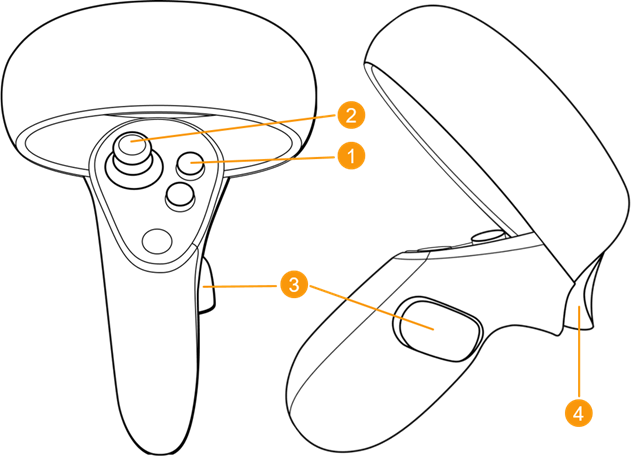
</div>

Source: [Controllers VRED 2025 AutoDesk](https://help.autodesk.com/view/VREDPRODUCTS/2025/ENU/?guid=VRED_VR_and_VR_Setup_Using_the_Oculus_Rift_with_VRED)


# Changing the visualization

First of all, we need to save our simulation in a file our app can read.  

We will save it inside the path you can see in red color, and it will be named as ```TEAD_complex.xml```

In [158]:
with open('openmm/openmm_files/TEAD_complex.xml', 'w') as outfile:
    outfile.write(serializer.serialize_simulation(simulation))

We are defining two auxiliar functions we are using.  

- The first one will allow us to use MDAnalysis syntax to make selections to visualize our simulation.

- The second one will be for setting a color map for some representation.

In [53]:
def generate_mdanalysis_selection(selection: str):
    universe = frame_data_to_mdanalysis(client.first_frame)
    idx_array = universe.select_atoms(selection).indices
    return map(int, idx_array)

In [54]:
def get_matplotlib_gradient(name: str):
    cmap = matplotlib.colormaps[name]
    return list(list(cmap(x/7)) for x in range(0, 8, 1))

We need to create a client to be able to modify the representations inside the app.

In [55]:
from nanover.app import NanoverImdClient
client = NanoverImdClient.connect_to_single_server(port=imd_runner.app_server.port)
client.subscribe_to_frames()
client.wait_until_first_frame();
# Begin tracking updates to the shared multiplayer values
client.subscribe_multiplayer()

This will hide the "root_selection". 

By default, we are seeing the proteins displayed as "Ball and Stick" representation. However, we can change this for a better visualization!

In [81]:
root_selection = client.root_selection
with root_selection.modify():
    root_selection.hide =  True
    root_selection.interaction_method = 'single'

In this simulation we have two proteins, in other words, two chains. 

- Chain A is **YAP/TAZ**   
- Chain B is **TEAD**

So, through the client we created before, we define to selections

In [57]:
chain_A = client.create_selection("chain_A", [])
chain_B = client.create_selection("chain_B", [])
resA_nearB = client.create_selection("resA_nearB", [])

First of all, we are going to check both of the chains, and diferentiate them.  

The selection is telling the app what we want (or expect) to see. 

With the function we created before, we are selecting ```segid A and not type H``` so we are displaying just the **Chain A** and we are hiding the Hydrogens from it.

This representation by default is called _**Liquorice**_


In [86]:
with chain_A.modify():
    chain_A.set_particles(generate_mdanalysis_selection("segid A and not type H"))

Now we will hide it


In [79]:
with chain_A.modify():
    chain_A.hide = True

The other protein, Chain B corresponds to TEAD protein. Let's see it!

Again, we are selecting ```segid B and not type H``` displaying just the **Chain B** of our simulation.

In [82]:
with chain_B.modify():
    chain_B.set_particles(generate_mdanalysis_selection("segid B and not type H"))

In [83]:
with chain_B.modify():
    chain_B.hide = True

Okay, we saw both proteins, we can distinguish them one to another, but if we have the whole system displayed is a mess to distinguish the proteins in the same representation.  

So let's make it easier (and prettier 😏)

**Select Chain A**

In [100]:
with chain_A.modify():
    chain_A.hide = False
    chain_A.set_particles(generate_mdanalysis_selection("segid A and not type H"))
    chain_A.renderer = {
        "color": "cpk",
        "render": "liquorice"
    }

**Select Chain B**

In [96]:
with chain_B.modify():
    chain_B.hide = False
    chain_B.set_particles(generate_mdanalysis_selection("segid B and not type H"))
    chain_B.renderer = {
        "color": "gold",
        "render": "liquorice"
    }

Apply color gradient Viridis to the Chain A 

In [240]:
with chain_A.modify():
    chain_A.renderer = {
    # 'cartoon'

            'sequence': 'entity',
            'color': {
                'type': 'residue index in entity',
                'gradient': get_matplotlib_gradient('viridis')
            },
            'render': 'ball and sticks'
        }

Apply color gradient Magma to Chain B

In [98]:
with chain_B.modify():
    chain_B.renderer = {
    # 'cartoon'

            'sequence': 'entity',
            'color': {
                'type': 'residue index in entity',
                'gradient': get_matplotlib_gradient('magma')
            },
            'render': 'liquorice',
            'scale': 0.08
        }

Another way to see the whole structure is by applying _Cartoon_ representation.  

In this case, we are able to see both chains in Cartoon but is difficult to separate one to another

Colors particles by their **Secondary Structure** (_Cartoon_ representation), calculated using the DSSP algorithm. Currently the color is hard coded to:

- Yellow for beta sheets
- Red for pi helices
- Magenta for alpha helices
- Blue for 3-10 helices
- White for everything else

These colors will be modifiable in a future update.

In [101]:
with chain_A.modify():
    chain_A.hide = False
    chain_A.set_particles(generate_mdanalysis_selection("segid A and not type H"))
    chain_A.renderer = 'cartoon'

In [ ]:
# Remove all selections
client.clear_selections()

In [242]:
arginine = client.create_selection("ARG", [])

with arginine.modify():
    arginine.hide = False
    arginine.set_particles(generate_mdanalysis_selection("segid A and resname ARG"))
    arginine.renderer = {
        "color": "red",
        "render": "ball and sticks",
        "scale": 0.1
    }

In [94]:
with resA_nearB.modify():
    resA_nearB.set_particles(generate_mdanalysis_selection("segid A and same resid as around 2 segid B"))
    resA_nearB.renderer = {
        "color": "gold",
        "render": "liquorice",
        "scale": 0.1
    }

In [80]:
# Remove all selections
client.clear_selections()

# secondary structure
Colors particles by their secondary structure, calculated using the DSSP algorithm. Currently the color is hard coded to:

- Yellow for beta sheets
- Red for pi helices
- Magenta for alpha helices
- Blue for 3-10 helices
- White for everything else  

These colors will be modifiable in a future update.

In [46]:
client.close()
imd_runner.close()